# Sample variance simulation

This notebook modifies the simulation example from earlier in class to simulate sample *variances* rather than means. 

It is a useful notebook to work through to help understand the latter parts of the first HW assignment.

As before we will assume i.i.d. (independent and identically distributed data) from a Normal distribution. In this case, we will set the true mean to zero  (although this can be changed) and the true standard deviation to 5 (this also can be changed), so that the true variance is $5^2 = 25$.

## Basic setting and key result

The idea is that we observe outcomes from an i.i.d. normal distribution. We want to estimate the (unknown) true variance. 

As a reminder, remember that previously, when we considered estimating the *mean*, we derived that the sample mean was *unbiased*, meaning $E(\bar{X})= \mu$, where $\mu$ is the true mean, and it had a variance equal to $\sigma^{2}/N$, and therefore a standard deviation equal to $\sigma/\sqrt{N}$. In addition, if the data are i.i.d. normally distributed, then the mean is also normally distributed. These results allowed us to perform statistical inference regarding the mean.

Now we want to consider estimating the *variance* rather than the mean. 

We will consider two, very closely related estimates of the variance:

1. $s^2 = \frac{1}{N-1} \sum_{n=1}^{N} (X_{i} - \bar{X})^{2}$

2. $\tilde{s}^2 = \frac{1}{N} \sum_{n=1}^{N} (X_{i} - \bar{X})^{2}$

Note:  $\bar{X}$ is the sample mean in the above. 

It can be shown that:

1. $E(s^2) = \sigma^2$   (so the estimator is *unbiased*)
2. $E(\tilde{s}^{2}) = \frac{N-1}{N} \sigma^{2}$

As an illustration of the bias of $\tilde{s}^2$, below we will consider a scenario where $\sigma^2 = 25$ and $N=20$. Plugging in, we have: 

$E(\tilde{s}^{2}) = \frac{N-1}{N} \sigma^{2} = (19/20) \times 25 = 23.75$. 

The second estimator $\tilde{s}^2$ is a direct "plug-in" estimator of the variance: it computes the sample average of squared deviations from the mean. It turns out that this estimator is *downward biased* meaning that on average it is lower than the true variance. The intuitive reason for this is that it does not account for the fact that the true mean is unknown and has been replaced by the sample mean in the definition of the estimator. In contrast, the first estimator $s^2$ accounts for this by making a "degree of freedom" correction that divides the sum of squared deviations by $N-1$ rather than $N$. When $N$ is relatively large, the bias of $\tilde{s}^2$ is small, and the two estimators are numerically very similar. But, for small $N$, the difference can be important.

Key inference result: $\frac{N-1}{\sigma^2} s^2 \sim \chi^{2}_{N-1} $, or, equivalently, $s^2 \sim \frac{\sigma^2}{N-1} \chi^{2}_{N-1}$

Using the fact that the variance of a Chi-squared random variable is twice the degrees of freedom, we can determine after a bit of algebra that the standard deviation of the sample variance equals:

$\text{Std. Dev.}(s^2) = \sqrt{\frac{2}{N-1}} \sigma^2$

The problem with the above result is that $\sigma^2$ is unknown -- after all, this is what we are trying to estimate! So we cannot compute the standard deviation using the previous formula in practice. The standard resolution is to "plug-in" $s^2$ as an estimate for the unknown $\sigma^2$. This gives the following estimate of the standard deviation of the variance:

$\widehat{\text{Std. Dev.}(s^2)} = \sqrt{\frac{2}{N-1}} s^2$

Notice that the standard deviation of the variance estimate goes to zero as $N \rightarrow \infty$. Putting this together with the unbiased property above, this shows that $s^2$ is a *consistent* estimator of the true variance: the sample variance converges (in probability) to the true variance as the sample size becomes arbitrarily large. (The alternative estimator $\tilde{s}^2$ is also consistent, despite its finite sample bias, because the bias disappears as the sample size gets large.)

The following simulation illustrates the properties of the estimate of the variance.



In [1]:
#We will need some Python modules
import numpy as np
import pandas as pd

#Let's set the key parameters

#true mean
xmu = 0
#true std
xstd = 5

#sample size (can be changed of course)
N = 20


print("Theoretical std. dev. of variance estimate:", np.sqrt(2/(N-1))*(xstd**2))


Theoretical std. dev. of variance estimate: 8.111071056538128


## One sample
Next, we will generate *one* sample of data and compute the sample variance. We will see that the sample variance does not correspond to the true variance, due to the effects of sampling error.

Python code:

In [2]:
#Do one simulation to illustrate
rng = np.random.RandomState(10)  # deterministic random data
sim_x = rng.normal(loc=xmu, scale=xstd, size=N)

print("Here is our first simulated set of data: ", sim_x)

#Now compute the sample variance
#Note: the numpy "np.var()" function computes the biased (plug-in) estimator, tilde{s}^2 (dividing by N)

svar_biased = np.var(sim_x)
#Now compute the unbiased version, s^2 (dividing by N-1)
svar_unbiased = N/(N-1) * svar_biased
print("Here is the biased (plug-in) variance estimate for this sample", svar_biased)
print("Here is the unbiased variance estimate for this sample", svar_unbiased)
print("Neither equals the true value (25)! This is not surprising and is due to sampling error")





Here is our first simulated set of data:  [ 6.65793252  3.57639487 -7.72700146 -0.04191925  3.10667987 -3.6004278
  1.32755793  0.54274263  0.02145715 -0.87300105  2.16513095  6.01518687
 -4.82532835  5.14137039  1.14315065  2.22568806 -5.68301106  0.67568439
  7.42268501 -5.39902443]
Here is the biased (plug-in) variance estimate for this sample 17.45305194607302
Here is the unbiased variance estimate for this sample 18.371633627445284
Neither equals the true value (25)! This is not surprising and is due to sampling error


## More simulations

Now we will do a lot of simulations similar to the above. This will give us many realizations of the sample variance, and we can then confirm (up to a tiny bit of simulation error) the analytical results summarized above.

In [3]:
#number of simulations (we generally want this to be 'large' so that we get the approximate properties of the estimator)
B = 5000

#Initialize a holder for our sample variance estimates
sim_outcomes_biased = []
sim_outcomes_unbiased = []
#Now we will do a loop in python:

for i in np.arange(0,B):
    #simulate new data
    sim_x = np.random.normal(loc=xmu, scale=xstd, size=N)
    #compute the biased (plug-in) variance estimate, tilde{s}^2
    svar_biased = np.var(sim_x)
    #keep the variance we computed
    sim_outcomes_biased.append(svar_biased)
    #repeat for unbiased version, s^2
    svar_unbiased = (N/(N-1))*svar_biased
    sim_outcomes_unbiased.append(svar_unbiased)

#make a Pandas DataFrame 
data = {'Svar_biased': sim_outcomes_biased, 'Svar_unbiased': sim_outcomes_unbiased}
sim_df = pd.DataFrame(data)

sim_df.head(20)
    

,Svar_biased,Svar_unbiased
0,25.201463,26.527856
1,12.348195,12.998100
2,27.227494,28.660520
3,34.607372,36.428813
4,30.945616,32.574333
5,19.506127,20.532765
6,15.890042,16.726360
7,23.835061,25.089538
8,24.285375,25.563553
9,20.980870,22.085126


In [4]:
#report descriptive statistics for the sample means
sim_df.describe()



,Svar_biased,Svar_unbiased
count,5000.000000,5000.000000
mean,23.865684,25.121772
std,7.708863,8.114592
min,5.780263,6.084488
25%,18.331624,19.296446
50%,23.083378,24.298293
75%,28.462779,29.960820
max,69.332445,72.981522


## Interpretation of the simulation results

Earlier, we showed that $s^2$ is unbiased, and so its mean should equal the true variance of 25. The simulation-based computation of the mean is very close to this. Similarly, we showed that $\tilde{s}^2$ is downward biased and should have a mean of 23.75. Again, the simulation based average is very close to this.

Earlier we computed that the standard deviation of the variance estimate equals $\sqrt{\frac{2}{N-1}} \sigma^2 = \sqrt{\frac{2}{19}} 25 = 8.11$ for our parameter choices. Notice that the simulation-based standard deviation of the variance estimate is extremely close to this theoretical value. 

Finally, the key distributional result stated that  $\frac{N-1}{\sigma^2} s^2 \sim \chi^{2}_{N-1} $. The code below plots a histogram that validates this result. 

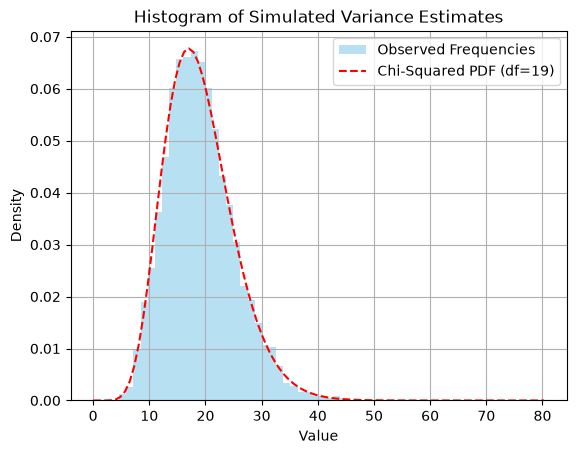

In [5]:
import matplotlib.pyplot as plt

# Create the histogram
y = ((N-1)/xstd**2)*sim_df["Svar_unbiased"]
plt.hist(y, bins=40, density=True, alpha=0.6, color='skyblue', label='Observed Frequencies')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Simulated Variance Estimates')

#Here we will add a line that plots the theoretical pdf (prob. density function) of the sample variance for comparison
from scipy.stats import chi2

df = N-1

# Define the range for the chi-squared PDF
x = np.linspace(0, max(sim_df["Svar_unbiased"]) * 1.1, 100)

# Calculate the PDF of the chi-squared distribution
pdf = chi2.pdf(x, df)

# Plot the chi-squared PDF as a reference curve
plt.plot(x, pdf, color='red', linestyle='--', label=f'Chi-Squared PDF (df={df})')
plt.legend()
plt.grid(True)
plt.show()

You can see that the histogram shape is consistent with the theoretical distribution (as it should be). 



## Confidence interval for variance estimate

HW \#1 asks you to compute a 95\% confidence interval for the estimated variance using some stock return data. Above, we showed that the standard deviation of the variance estimate can be computed as:

$\widehat{\text{Std. Dev.}(s^2)} = \sqrt{\frac{2}{N-1}} s^2$.

With this calculation in hand, a 95\% confidence interval for the variance can be computed as:

$s^{2} \pm 1.96 \times \widehat{\text{Std. Dev.}(s^2)} $

